<a href="https://colab.research.google.com/github/nawrin1/First_Program_SM/blob/main/L11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup & Imports

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt



import warnings
warnings.filterwarnings('ignore')

# 2. Mount Drive & Load Dataset

In [16]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/datasets/diabetes_prediction_dataset.csv')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# 3. Data Preprocessing

In [17]:

df.dropna(inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

near_constant = [
    c for c in df.columns
    if c != 'diabetes'
    and df[c].value_counts(normalize=True).iloc[0] > 0.99
]


df.drop(columns=near_constant, inplace=True)


df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


# 4. Train-Test Split

In [18]:
X = df.drop(columns=['diabetes'])
y = df['diabetes']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=20,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (80000, 8) | Test: (20000, 8)


# 5. Model Training — SVM & Naive Bayes

In [19]:
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=20
)


svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:,1]


In [20]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

y_prob_nb = nb_model.predict_proba(X_test)[:,1]


# 6. Evaluation Metrics — Precision, Recall, F1-Score

In [21]:
print('='*55)
print('SVM Classification Report')
print('='*55)

print(
    classification_report(
        y_test,
        y_pred_svm,
        digits=4,
        target_names=['No Diabetes','Diabetes']
    )
)


print('='*55)
print('Naive Bayes Classification Report')
print('='*55)


print(
    classification_report(
        y_test,
        y_pred_nb,
        digits=4,
        target_names=['No Diabetes','Diabetes']
    )
)

SVM Classification Report
              precision    recall  f1-score   support

 No Diabetes     0.9638    0.9985    0.9808     18300
    Diabetes     0.9731    0.5965    0.7396      1700

    accuracy                         0.9643     20000
   macro avg     0.9685    0.7975    0.8602     20000
weighted avg     0.9646    0.9643    0.9603     20000

Naive Bayes Classification Report
              precision    recall  f1-score   support

 No Diabetes     0.9662    0.9213    0.9432     18300
    Diabetes     0.4351    0.6529    0.5222      1700

    accuracy                         0.8984     20000
   macro avg     0.7007    0.7871    0.7327     20000
weighted avg     0.9210    0.8984    0.9074     20000



# 7. ROC-AUC Curve Comparison

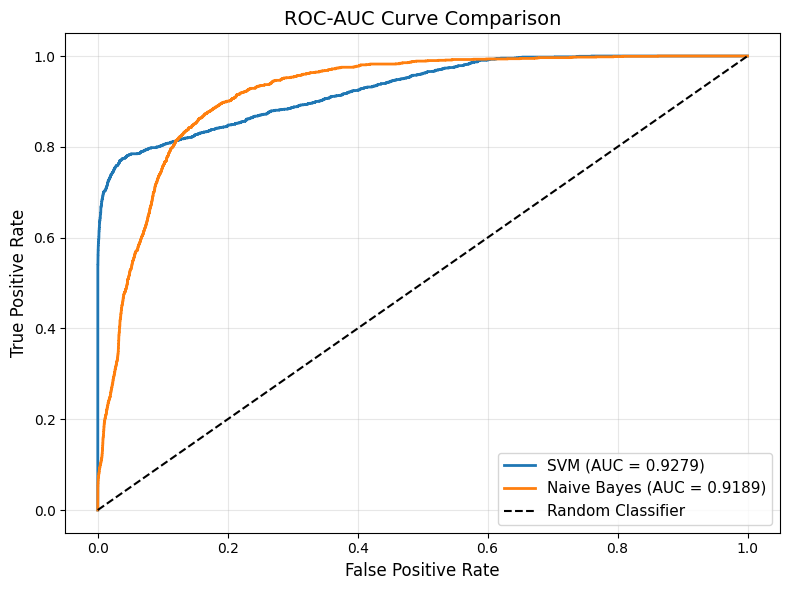

In [22]:
fpr_svm, tpr_svm, _ = roc_curve(
    y_test,
    y_prob_svm
)

fpr_nb, tpr_nb, _ = roc_curve(
    y_test,
    y_prob_nb
)
auc_svm = roc_auc_score(
    y_test,
    y_prob_svm
)
auc_nb = roc_auc_score(
    y_test,
    y_prob_nb
)
plt.figure(figsize=(8,6))
plt.plot(
    fpr_svm,
    tpr_svm,
    label=f'SVM (AUC = {auc_svm:.4f})',
    linewidth=2
)


plt.plot(
    fpr_nb,
    tpr_nb,
    label=f'Naive Bayes (AUC = {auc_nb:.4f})',
    linewidth=2
)
plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random Classifier')
plt.xlabel(
    'False Positive Rate',
    fontsize=12)


plt.ylabel(
    'True Positive Rate',
    fontsize=12)


plt.title(
    'ROC-AUC Curve Comparison',
    fontsize=14
)


plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/datasets/diabetes_roc_auc_curve.png',
    dpi=300
)


plt.show()

# 8. Results Summary Table

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
results = pd.DataFrame({

    'Model': [
        'SVM (RBF)',
        'Naive Bayes'
    ],


    'Accuracy': [

        accuracy_score(
            y_test,
            y_pred_svm
        ),

        accuracy_score(
            y_test,
            y_pred_nb
        )
    ],


    'Precision': [

        precision_score(
            y_test,
            y_pred_svm
        ),

        precision_score(
            y_test,
            y_pred_nb
        )
    ],


    'Recall': [

        recall_score(
            y_test,
            y_pred_svm
        ),

        recall_score(
            y_test,
            y_pred_nb
        )
    ],


    'F1-Score': [

        f1_score(
            y_test,
            y_pred_svm
        ),

        f1_score(
            y_test,
            y_pred_nb
        )
    ],


    'ROC-AUC': [

        auc_svm,
        auc_nb
    ]

})

results.iloc[:,1:] = results.iloc[:,1:].round(4)


results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM (RBF),0.9643,0.9731,0.5965,0.7396,0.9279
1,Naive Bayes,0.8984,0.4351,0.6529,0.5222,0.9189
